In [3]:
# decision tree with function
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
df=pd.read_csv("/content/bankloan.csv")
df

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [5]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [7]:
X = df.drop("Personal.Loan", axis=1)
y = df["Personal.Loan"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [28]:
y_pred=model.predict(X_test)
print("Accuracy_score = ",accuracy_score(y_test,y_pred))
print("Confusion_matrix = ",confusion_matrix(y_test,y_pred))
print("Classification_report = ",classification_report(y_test,y_pred))


Accuracy_score =  0.986
Confusion_matrix =  [[889   6]
 [  8  97]]
Classification_report =                precision    recall  f1-score   support

           0       0.99      0.99      0.99       895
           1       0.94      0.92      0.93       105

    accuracy                           0.99      1000
   macro avg       0.97      0.96      0.96      1000
weighted avg       0.99      0.99      0.99      1000



In [12]:

new_input = [[1,30,3,100,76009,4,5.3,3,0,1,0,0,1]]
prediction = model.predict(new_input)

if prediction[0] == 1:
    print("Loan Approved ✅")
else:
    print("Loan Not Approved ❌")

Loan Approved ✅


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


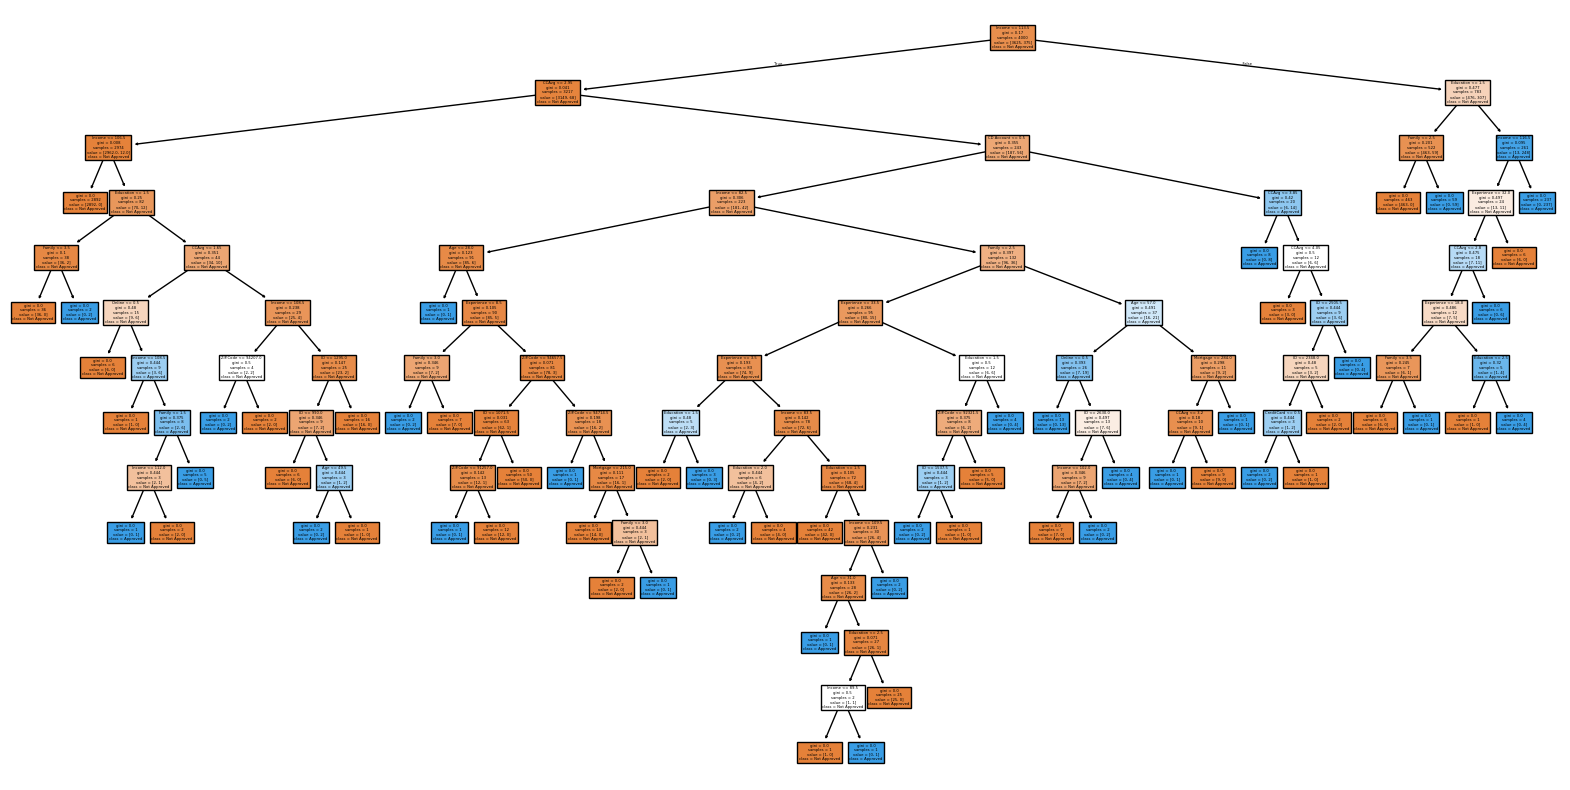

In [13]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Approved", "Approved"],
    filled=True
)
plt.show()

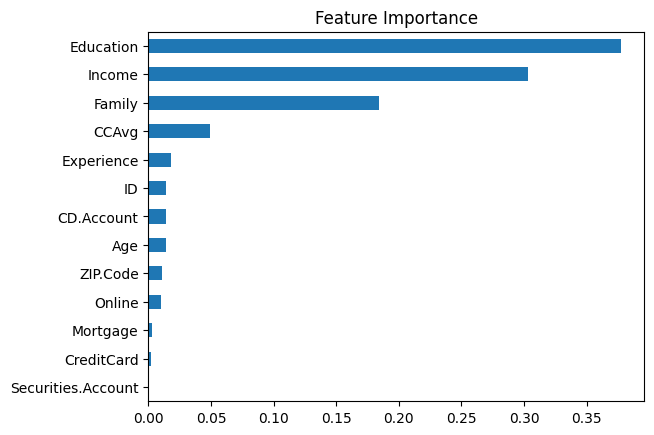

In [14]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [16]:
# decison tree using python i.e. no use of inbuilt functions


In [17]:
# Format: [Income, CreditScore, LoanApproved]
dataset = [
    [5000, 700, 1],
    [3000, 600, 0],
    [8000, 750, 1],
    [2000, 500, 0],
    [6000, 720, 1],
    [2500, 580, 0]
]

In [18]:
def gini_index(groups, classes):
    total_samples = sum(len(group) for group in groups)
    gini = 0.0

    for group in groups:
        size = len(group)
        if size == 0:
            continue

        score = 0.0
        for class_val in classes:
            proportion = [row[-1] for row in group].count(class_val) / size
            score += proportion ** 2

        gini += (1 - score) * (size / total_samples)

    return gini

In [19]:
def test_split(index, value, dataset):
    left, right = [], []
    for row in dataset:
        if row[index] < value:
            left.append(row)
        else:
            right.append(row)
    return left, right

In [20]:
def get_best_split(dataset):
    class_values = list(set(row[-1] for row in dataset))
    best_index, best_value, best_score, best_groups = 999, 999, 999, None

    for index in range(len(dataset[0]) - 1):
        for row in dataset:
            groups = test_split(index, row[index], dataset)
            gini = gini_index(groups, class_values)

            if gini < best_score:
                best_index, best_value, best_score, best_groups = index, row[index], gini, groups

    return {'index': best_index, 'value': best_value, 'groups': best_groups}

In [21]:
def to_terminal(group):
    outcomes = [row[-1] for row in group]
    return max(set(outcomes), key=outcomes.count)

In [22]:
def split(node, max_depth, min_size, depth):
    left, right = node['groups']
    del(node['groups'])

    # If one side empty
    if not left or not right:
        node['left'] = node['right'] = to_terminal(left + right)
        return

    # Max depth reached
    if depth >= max_depth:
        node['left'], node['right'] = to_terminal(left), to_terminal(right)
        return

    # Process left
    if len(left) <= min_size:
        node['left'] = to_terminal(left)
    else:
        node['left'] = get_best_split(left)
        split(node['left'], max_depth, min_size, depth+1)

    # Process right
    if len(right) <= min_size:
        node['right'] = to_terminal(right)
    else:
        node['right'] = get_best_split(right)
        split(node['right'], max_depth, min_size, depth+1)

In [23]:
def build_tree(train, max_depth, min_size):
    root = get_best_split(train)
    split(root, max_depth, min_size, 1)
    return root

tree = build_tree(dataset, max_depth=3, min_size=1)
print(tree)

{'index': 0, 'value': 5000, 'left': {'index': 0, 'value': 3000, 'left': {'index': 0, 'value': 2000, 'left': 0, 'right': 0}, 'right': 0}, 'right': {'index': 0, 'value': 5000, 'left': 1, 'right': 1}}


In [24]:
def predict(node, row):
    if row[node['index']] < node['value']:
        if isinstance(node['left'], dict):
            return predict(node['left'], row)
        else:
            return node['left']
    else:
        if isinstance(node['right'], dict):
            return predict(node['right'], row)
        else:
            return node['right']

In [25]:
new_customer = [4000, 650]  # Income, CreditScore
result = predict(tree, new_customer)

if result == 1:
    print("Loan Approved ✅")
else:
    print("Loan Not Approved ❌")

Loan Not Approved ❌


In [26]:
def print_tree(node, depth=0):
    if isinstance(node, dict):
        print(" " * depth + f"[X{node['index']} < {node['value']}]")
        print_tree(node['left'], depth + 4)
        print_tree(node['right'], depth + 4)
    else:
        print(" " * depth + f"--> Class: {node}")

In [27]:
print("Decision Tree:")
print_tree(tree)

Decision Tree:
[X0 < 5000]
    [X0 < 3000]
        [X0 < 2000]
            --> Class: 0
            --> Class: 0
        --> Class: 0
    [X0 < 5000]
        --> Class: 1
        --> Class: 1
